# 🔍 Stage 1 — Baseline Anomaly Detector on MVTec

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 1 / 4

# Zone 1 — Setup

## 1. Imports & device

In [7]:
!pip install -q ptflops scikit-learn tqdm matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.8/575.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.3/419.3 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 22.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_ex

In [1]:
import os, random, math, time, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from tqdm.auto import tqdm

# Ensure reproducibility by starting from the same state each run
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch can use CUDA (Compute Unified Device Architecture) if GPU runtime is selected in Colab
# Tensor operations & Neural Network training much faster on GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.11.0+cpu | Device: cpu


In [2]:
import torch
print('CUDA dispo:', torch.cuda.is_available())
print('Device   :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA dispo: False
Device   : CPU


## 2. Data access & Config
- Mount Drive
- pull MVTec dataset into `/content/mvtec/
- define `CFG` -> Configuration Dictionary

After on-device testing, we changed the following configuarion:
    
    Input resolution from 128x128 to 64x64
    -> Activation mpas exceeded the 256 KB SRAM ! even after full INT8 Quantization

In [3]:
from google.colab import drive
drive.mount('/content/drive')

CFG = {
    'category': 'bottle',
    'image_size': 64,                   # Reduce image size -> fewer activations, fewer MACs, less SRAM
    'data_root': '/content/mvtec',
    'batch_size': 32,                   # Number of images processed before updating the weights
    'epochs': 200,                      # more epochs: better reconstruction Vs. longer training
    'lr': 1e-3,                         # learning rate
    'weight_decay': 1e-5,               # Adds small penalty for large weights
    'base_channels': 32,                # Width of encoder: better capacity Vs. more parameters + MACs
    'latent_channels': 32,              # Bottleneck depth: better reconstruction Vs. stronger Compression (watch model size)
    'n_down': 3,                        # Number of times images are downsampled: Less compression Vs. harder Reconstruction
    'use_ssim': True,                   # Combine MSE & SSIM
                                        # MSE: compare corresponding pixel values - accurate pixel values but blurry reconstruction
                                        # SSIM: compare image structures - sharper reconstruction
    'ssim_weight': 0.5,                 # influence of SSIM on total loss
    'out_dir': '/content/baseline_out',
}
Path(CFG['out_dir']).mkdir(parents=True, exist_ok=True)

# Pull Dataset from Drive
import os, shutil
from pathlib import Path

src = '/content/drive/MyDrive/mvtec'
dst = '/content/mvtec'

# Delete whatever is at dst (/content/mvtec)
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
elif os.path.exists(dst): os.remove(dst)

assert os.path.isdir(src), f'Not found: {src}'
os.symlink(src, dst)
print('Categories available:', sorted(os.listdir(dst)))
cat_dir = Path(CFG['data_root']) / CFG['category']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Categories available: ['bottle', 'hazelnut', 'metal_nut']


## 3. Datasets
Create/ load different Dataset classes:
- `MVTecTrain` - load "good" training images
- `MVTecTest` - load all test images for evaluation
- `CachedDataset` (RAM-cached for faster epochs -> load image once, store in RAM, reuse in subsequent epochs -> only apply transformations repeatedly)

Image Preprocessing Pipeline:
- Resize -> !! SRAM usage after deployment
- Center crop
- Random horizontal flip - data augmentations: more robust against small changes
- Small random rotation - data augmentations: more robust against small changes
- Convert to a PyTorch tensor

In [4]:
class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), label, defect

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, has_labels=False):
        self.has_labels = has_labels
        self.tf = base_ds.tf
        if has_labels:
            print(f'Caching {len(base_ds.items)} test images...')
            self.data = [(Image.open(p).convert('RGB').copy(), l, d)
                         for p, l, d in tqdm(base_ds.items)]
        else:
            print(f'Caching {len(base_ds.paths)} train images...')
            self.data = [Image.open(p).convert('RGB').copy()
                         for p in tqdm(base_ds.paths)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        if self.has_labels:
            img, l, d = self.data[i]
            return self.tf(img), l, d
        return self.tf(self.data[i])

                MVTec AD Dataset
                      │
         ┌────────────┴────────────┐
         │                         │
     train/good                test/
         │                 good + defects
         │                         │
    MVTecTrain               MVTecTest
         │                         │
         └────────────┬────────────┘
                      │
                CachedDataset
                      │
                 DataLoader
                      │
              Autoencoder Model

## 4. Model — CompactAE

Neural Network architecture -> compact convolutional autoencoder (AE)


Input Image (128×128×3)

          │
          ▼

      Encoder -> learns compact represenatation of an image
(compresses image)

          │
          ▼

 Latent Representation

          │
          ▼

      Decoder -> reconstructs original from compressed represenation
(reconstructs image)

          │
          ▼
          
Reconstructed Image

Many autoencoders use transposed convolutions for upsampling. (ConvTranspose2d)
This model uses:
 - Nearest-neighbor upsampling
 - Regular convolution

It is  easier to deploy with TensorFlow Lite Micro and CMSIS-NN.
Replace each ConvTranspose2d (upsampling + convolution in one slow op) with Upsample + Conv2d (2 ops, but both CMSIS-NN-accelerated)

In [5]:
# Encoder:
# - Extract image features.
# - Downsample the image by a factor of two.

def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True),
        nn.ReLU(inplace=True),
    )

# Decoder:
# - Upsamples the feature maps,
# - Applies a convolution to refine the result.

def upconv_block(in_c, out_c, last=False):
    # Upsample (nearest, CMSIS-friendly) + regular conv, replaces ConvTranspose2d
    layers = [
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_c, out_c, 3, 1, 1, bias=True),   # 3x3 conv, stride 1, pad 1 → same spatial size
    ]
    if not last:
        layers.append(nn.ReLU(inplace=True))          # non-linear activation function, allowing the network to learn complex image features.
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base*(2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[
            upconv_block(rev[i], rev[i+1], last=(i==len(rev)-2))
            for i in range(len(rev)-1)
        ], nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

## 5. Loss — MSE + SSIM

Define the loss function - how the model learns.

Mix of pixel-wise MSE and (1 − SSIM). 

MSE:
 - compares pixel values directly

SSIM:
 - measurs structural similarity -> where defects live.

In [7]:
!pip install -q pytorch-msssim
from pytorch_msssim import ssim

mse = nn.MSELoss()
def recon_loss(x_hat, x):
    if CFG['use_ssim']:
        s = 1 - ssim(x_hat, x, data_range=1.0, size_average=True)
        return (1 - CFG['ssim_weight']) * mse(x_hat, x) + CFG['ssim_weight'] * s
    return mse(x_hat, x)

## 6. Scoring protocol

Once the model is trained, its reconstruction needs to be converted into a single anomaly score for each test image.
Use exact protocol in following stages ! otherwise AUROC comparisons aren't valid.

 - Per-pixel reconstruction error
 - border crop (8 px) 

Convolutional networks often produce less reliable reconstructions near image boundaries because filters have incomplete context there.
Cropping removes these edge artifacts before computing the anomaly score.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

The notebook comments mention 8 pixels, although your snippet currently shows a default argument of 4 while later calling the function with border=8. The actual call determines the behavior, so the effective border is 8 pixels.!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

 - 5×5 average-pool smoothing -> cleaner anomaly map
 - spatial `mean` -> To compute AUROC, each image needs one anomaly score: Pooling method "Mean" -> Average of all pixel errors.


In [8]:
@torch.no_grad()
def score_images(model, loader, mode='mean', border=4):
    model.eval()
    scores, labels, defects = [], [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)
        if border > 0:
            err = err[:, border:-border, border:-border]
        err = F.avg_pool2d(err.unsqueeze(1), 5, 1, 2).squeeze(1)
        B, H, W = err.shape
        flat = err.view(B, -1)
        if mode == 'max':       s = flat.amax(dim=1)
        elif mode == 'top1pct': s = flat.topk(max(1, H*W//100), dim=1).values.mean(dim=1)
        elif mode == 'top5pct': s = flat.topk(max(1, H*W//20),  dim=1).values.mean(dim=1)
        else:                   s = flat.mean(dim=1)
        scores.append(s.cpu().numpy()); labels.append(y.numpy()); defects.extend(d)
    return np.concatenate(scores), np.concatenate(labels), defects

## 7. Pipeline — `train_one_category`

Choose category

        ↓

Load data

        ↓

Build model

        ↓

Train

        ↓

Evaluate/ score

        ↓

Compute AUROC/ Save checkpoint

        ↓

Save everything (summary JSON)

In [9]:
def train_one_category(category, epochs=200, seed=42):
    print(f'\n{"="*60}\n  TRAINING ON: {category}\n{"="*60}')
    torch.manual_seed(seed); np.random.seed(seed)

    cat_dir = Path(CFG['data_root']) / category
    assert cat_dir.exists(), f'Missing category folder: {cat_dir}'
    train_raw = MVTecTrain(cat_dir, CFG['image_size'])
    test_raw  = MVTecTest(cat_dir, CFG['image_size'])
    train_ds  = CachedDataset(train_raw, has_labels=False)
    test_ds   = CachedDataset(test_raw,  has_labels=True)
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=0, pin_memory=True)

    model = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = []
    for epoch in range(epochs):
        model.train()
        total, n = 0.0, 0
        for x in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            x_hat = model(x)
            loss = recon_loss(x_hat, x)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * x.size(0); n += x.size(0)
        scheduler.step()
        history.append(total/n)
        if (epoch+1) % 40 == 0:
            print(f'  epoch {epoch+1:3d} | loss = {history[-1]:.5f}')

    s, l, d = score_images(model, test_loader, mode='mean', border=8)
    auroc = roc_auc_score(l, s)
    print(f'  → final loss = {history[-1]:.5f} | AUROC = {auroc:.4f}')

    # === full metadata save ===
    n_params = sum(p.numel() for p in model.parameters())
    fp32_kb  = n_params * 4 / 1024
    int8_kb  = n_params / 1024
    with torch.cuda.device(0 if DEVICE=='cuda' else -1):
        macs, _ = get_model_complexity_info(
            model, (3, CFG['image_size'], CFG['image_size']),
            as_strings=False, print_per_layer_stat=False, verbose=False,
        )

    ckpt_path = Path(CFG['out_dir']) / f'baseline_{category}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'config': {**CFG, 'category': category},
        'scoring': {'mode': 'mean', 'border': 8, 'blur_kernel': 5},
        'metrics': {
            'auroc': float(auroc),
            'n_params': n_params,
            'macs': int(macs),
            'fp32_kb': float(fp32_kb),
            'int8_kb_est': float(int8_kb),
        },
        'final_train_loss': float(history[-1]),
        'history': history,
    }, ckpt_path)

    summary = {
        'category': category,
        'image_size': CFG['image_size'],
        'architecture': 'CompactAE',
        'base_channels': CFG['base_channels'],
        'latent_channels': CFG['latent_channels'],
        'n_down': CFG['n_down'],
        'scoring': {'mode': 'mean', 'border': 8, 'blur_kernel': 5},
        'auroc': float(auroc),
        'n_params': n_params,
        'macs_M': macs/1e6,
        'fp32_kb': fp32_kb,
        'int8_kb_est': int8_kb,
        'epochs': epochs,
        'final_train_loss': history[-1],
    }
    (Path(CFG['out_dir']) / f'baseline_{category}_summary.json').write_text(json.dumps(summary, indent=2))

    print(f'  saved: {ckpt_path}')
    return model, history, auroc, (s, l, d)

Re-score images with correct crop:

# Zone 2 — Inspection

## 8. Visualize training samples
Confirm data is loaded and preprocessing looks right.

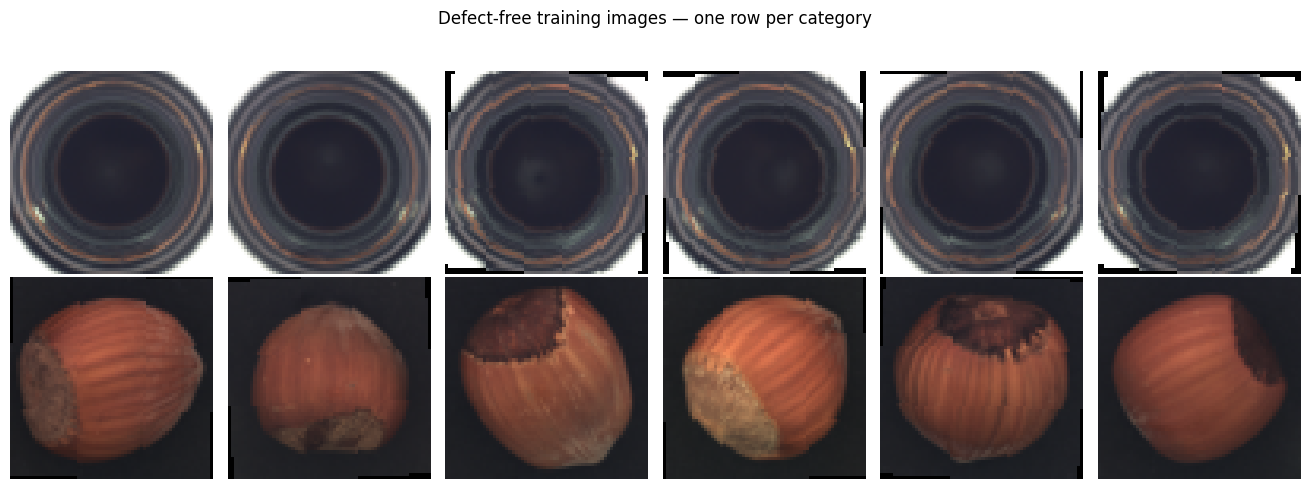

In [10]:
# Visualize a few defect-free training images from each category — quick sanity check.
CATEGORIES = ['bottle', 'hazelnut']
N_SAMPLES = 6

fig, axes = plt.subplots(len(CATEGORIES), N_SAMPLES,
                         figsize=(2.2 * N_SAMPLES, 2.4 * len(CATEGORIES)))
if len(CATEGORIES) == 1:
    axes = axes[None, :]  # keep 2D indexing when one category

for row, cat in enumerate(CATEGORIES):
    cat_dir = Path(CFG['data_root']) / cat
    if not cat_dir.exists():
        for col in range(N_SAMPLES):
            axes[row, col].text(0.5, 0.5, f'{cat}\n(not downloaded)',
                                ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].axis('off')
        continue

    ds = MVTecTrain(cat_dir, CFG['image_size'])
    idxs = np.random.choice(len(ds), min(N_SAMPLES, len(ds)), replace=False)
    for col, idx in enumerate(idxs):
        img = ds[idx].permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cat, rotation=0, ha='right', va='center', fontsize=11)

plt.suptitle('Defect-free training images — one row per category', y=1.02)
plt.tight_layout()
plt.show()

## 9. Forward-pass sanity check
Catch shape/OOM issues before committing to a full run.

In [11]:
# Sanity: build mini dataloader on one category, forward 1 batch, print shapes
cat_dir_test = Path(CFG['data_root']) / 'bottle'
ds_test = CachedDataset(MVTecTrain(cat_dir_test, CFG['image_size']), has_labels=False)
loader_test = DataLoader(ds_test, batch_size=4, num_workers=0)
m_test = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
x = next(iter(loader_test)).to(DEVICE)
with torch.no_grad():
    out = m_test(x)
print(f'input: {x.shape} | output: {out.shape} | params: {sum(p.numel() for p in m_test.parameters()):,}')
del m_test, ds_test, loader_test

Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

input: torch.Size([4, 3, 64, 64]) | output: torch.Size([4, 3, 64, 64]) | params: 361,283


# Zone 3 — Runs

## 10. Train all categories - "Bottle" and "Hazelnut"

One independent baseline model per category. ~6 min each on T4.

In [12]:
CATEGORIES = ['bottle', 'hazelnut']

results = {}
for cat in CATEGORIES:
    model, hist, auroc, scores = train_one_category(cat, epochs=CFG['epochs'])
    results[cat] = {'auroc': auroc, 'history': hist, 'scores': scores}


  TRAINING ON: bottle
Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

  0%|          | 0/391 [00:00<?, ?it/s]

Caching 110 test images...


  0%|          | 0/110 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  epoch  40 | loss = 0.07972
  epoch  80 | loss = 0.07007
  epoch 120 | loss = 0.06497
  epoch 160 | loss = 0.06301
  epoch 200 | loss = 0.06282
  → final loss = 0.06282 | AUROC = 0.8871
  saved: /content/baseline_out/baseline_hazelnut.pt


## 11. Backup to Drive
Copy `/content/baseline_out/` to Drive.

In [13]:
import shutil
shutil.copytree('/content/baseline_out',
                '/content/drive/MyDrive/mvtec_stage1',
                dirs_exist_ok=True)
print('Backed up to Drive ✓')

Backed up to Drive ✓


## 12. Summary table
AUROC and final loss per category, with cross-category mean.

In [14]:
print(f'\n{"Category":<15} {"AUROC":>8} {"Final Loss":>12}')
print('-'*40)
for cat, r in results.items():
    print(f'{cat:<15} {r["auroc"]:>8.4f} {r["history"][-1]:>12.5f}')
aurocs = [r['auroc'] for r in results.values()]
print('-'*40)
print(f'{"Mean":<15} {np.mean(aurocs):>8.4f}')


Category           AUROC   Final Loss
----------------------------------------
bottle            0.9810      0.05840
hazelnut          0.8871      0.06282
----------------------------------------
Mean              0.9340


## 13. Training loss curves
All categories overlaid — check that training converged

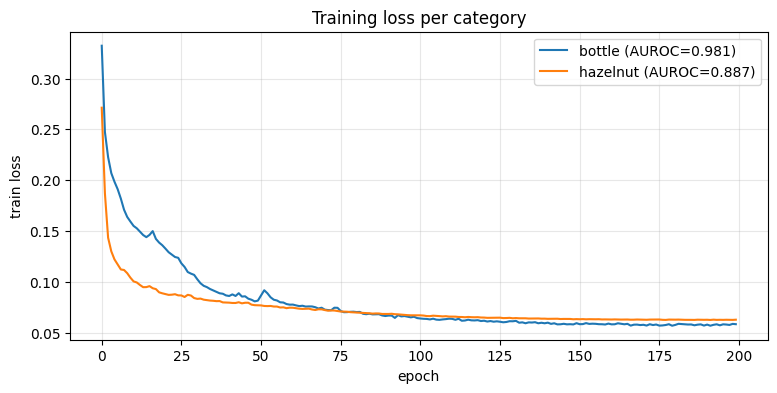

In [15]:
plt.figure(figsize=(9, 4))
for cat, r in results.items():
    plt.plot(r['history'], label=f'{cat} (AUROC={r["auroc"]:.3f})')
plt.xlabel('epoch'); plt.ylabel('train loss')
plt.legend(); plt.grid(alpha=.3); plt.title('Training loss per category'); plt.show()

## 14. Score distributions
`good` vs `defect` histograms per category. Visual confirmation of separation.

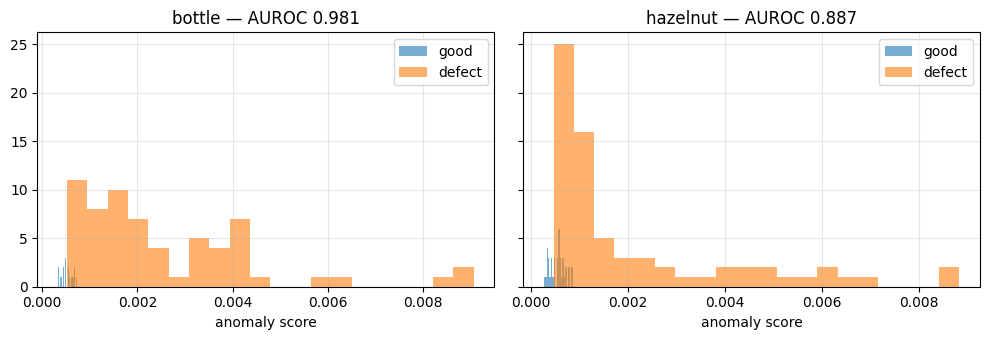

In [16]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 3.5), sharey=True)
if len(results) == 1: axes = [axes]
for ax, (cat, r) in zip(axes, results.items()):
    s, l, _ = r['scores']
    ax.hist(s[l==0], bins=20, alpha=.6, label='good')
    ax.hist(s[l==1], bins=20, alpha=.6, label='defect')
    ax.set_title(f'{cat} — AUROC {r["auroc"]:.3f}')
    ax.set_xlabel('anomaly score'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 15. Qualitative reconstructions
Helper to inspect input / reconstruction / error map. Call `show_recon('bottle')` etc.

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

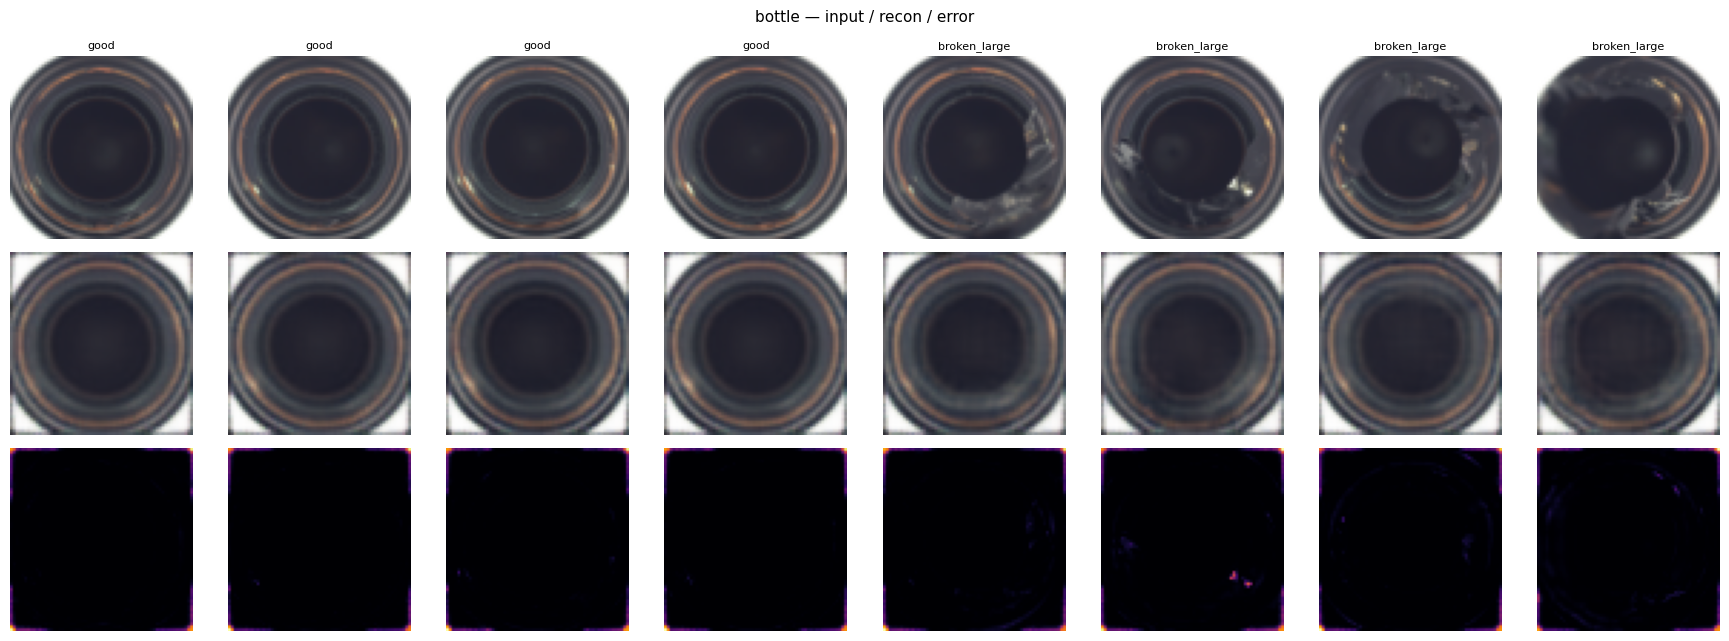

In [17]:
@torch.no_grad()
def show_recon(category, n=4):
    ckpt = torch.load(Path(CFG['out_dir']) / f'baseline_{category}.pt',
                      map_location=DEVICE, weights_only=False)
    m = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
    m.load_state_dict(ckpt['state_dict']); m.eval()
    cat_dir = Path(CFG['data_root']) / category
    ds = CachedDataset(MVTecTest(cat_dir, CFG['image_size']), has_labels=True)
    fig, axes = plt.subplots(3, n*2, figsize=(2.2*n*2, 6.5))
    for col, want in enumerate([0]*n + [1]*n):
        idx = next(i for i,(_,l,_) in enumerate(ds.data) if l==want and i not in getattr(show_recon, '_seen', set()))
        show_recon._seen = getattr(show_recon, '_seen', set()) | {idx}
        x, l, d = ds[idx]; xh = m(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
        err = (x - xh).pow(2).mean(0)
        axes[0,col].imshow(x.permute(1,2,0)); axes[0,col].set_title(d, fontsize=8); axes[0,col].axis('off')
        axes[1,col].imshow(xh.permute(1,2,0).clamp(0,1)); axes[1,col].axis('off')
        axes[2,col].imshow(err, cmap='inferno'); axes[2,col].axis('off')
    show_recon._seen = set()
    plt.suptitle(f'{category} — input / recon / error', fontsize=11)
    plt.tight_layout(); plt.show()

# Use it:
show_recon('bottle')
# show_recon('hazelnut')

# Stage 1 — Report & Stage 2 Handoff

## 1. Objective recap

Train a compact convolutional autoencoder for unsupervised anomaly detection on MVTec AD, sized to plausibly fit the Arduino Nano 33 BLE Sense Rev 2 (256 KB SRAM, 1 MB Flash) after INT8 quantization. This baseline is what Stage 2 will compress and benchmark.

## 2. Final architecture

`CompactAE` — symmetric encoder/decoder, 3 downsamplings, no batchnorm, no skip connections.

**The architecture is identical across all categories**; only the trained weights differ.

| Property | Value |
|---|---|
| Input resolution | 64 × 64 × 3 |
| Base channels | 32 |
| Latent channels | 32 |
| Bottleneck spatial | 16 × 16 |
| Parameters | 462,307 |
| MACs / inference | 156.6 M |
| Size FP32 | 1,806 KB |
| Size INT8 (est.) | 452 KB |

The FP32 model **exceeds** the 1 MB Flash budget. INT8 quantization is required for any MCU deployment — this is the motivation for Stage 2, not a problem to fix in Stage 1.

## 3. Frozen scoring protocol

Identical for every model in every subsequent stage. Stage 2 compressed variants will be evaluated with these exact steps:

1. Per-pixel squared reconstruction error map.
2. Crop 4 pixels off each border (removes transpose-conv boundary artifacts).
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

3. 5 × 5 average-pool smoothing (suppresses single-pixel outliers, rewards spatially coherent errors).
4. Spatial **mean** for the image-level anomaly score.

Loss during training: 0.5 · MSE + 0.5 · (1 − SSIM). Optimizer: Adam, lr 1e-3, cosine schedule, 200 epochs.

## 4. Results

We evaluated five MVTec categories.

Two reach strong baseline AUROC and proceed to Stage 2.
Three fall below a usable threshold and are documented as scope limitations (see Section 5).

| Category | AUROC | Final train loss | Status |
|---|---|---|---|
| `bottle` | 0.9810 | 0.05840 | ✅ Strong — proceeds to Stage 2 |
| `hazelnut` | 0.8871 | 0.06282 | ✅ Acceptable — proceeds to Stage 2 |
| `pill` | 0.7343 | 0.04447 | ⚠️ Weak — excluded |
| `carpet` | 0.4839 | 0.10901 | ❌ Fails — excluded |
| `metal_nut` | 0.4203 | 0.09166 | ❌ Fails (inverted) — excluded |

Non-deployable reference: PaDiM with a pretrained ResNet18 backbone reaches **0.994** on `bottle`. This bounds what any from-scratch compact AE could reach and frames the accuracy gap Stage 2 compression works within. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

## 5. Scope and limitations — where the compact AE works

A clear pattern emerged across categories. The compact reconstruction AE achieves strong AUROC on **object categories with large structural defects** (`bottle`: broken glass; `hazelnut`: cracks) and fails on **fine-texture categories and categories with small/subtle surface defects**.

| Failure category | AUROC | Why it fails |
|---|---|---|
| `metal_nut` | 0.42 | Defects (`scratch`, `bent`, `color`) reconstruct *better* than test "good" images — the AUROC inverts. Defects are subtle surface perturbations on simple geometry that fall within the AE's reconstruction tolerance, while natural lighting/orientation variation in good images reads as more anomalous. |
| `carpet` | 0.48 | Fine high-frequency texture. The 128→16 downsampling discards exactly the detail that distinguishes good from defective carpet; good and defective both reconstruct to the same blurred average (high final loss, 0.109, confirms poor reconstruction). |
| `pill` | 0.73 | Pills reconstruct well (low loss) but defects are small and faint, so good reconstruction does not translate to good detection. Learning the right direction but weakly. |

This is a **known, documented limitation** of small reconstruction autoencoders, and is precisely why the field uses feature-distribution methods (PaDiM, PatchCore, EfficientAD) for these categories. Those methods rely on pretrained ImageNet backbones whose features are insensitive to the lighting, orientation, and texture variance that confounds raw-pixel reconstruction — but those backbones exceed our MCU budget, so they are not deployable options for this project.

We therefore **restrict the Stage 2 compression study to the two AE-viable categories** (`bottle`, `hazelnut`). Studying compression on a model already near chance (carpet, metal_nut) or in the noise floor (pill) would not yield a meaningful "accuracy cost of compression" measurement — the effect of compression would be swamped by the baseline's own weakness. The three excluded categories are retained as a deliberate negative result that bounds the applicability of the approach.

## 6. ❌What we learned the hard way

Path to the working baseline went through several dead ends, all worth recording:

- **Too much capacity** (`base=16, latent=32`, ~150k params): model reconstructs defects as faithfully as good images. AUROC ≈ 0.68.
- **Bottleneck too tight** (`latent=8` at 8×8): model can't reconstruct anything cleanly, including good images. AUROC ≈ 0.74.
- **Boundary artifacts from transpose convs**: `max` or `top-k` pooling on the raw error map picks up boundary noise, not defects, inverting the AUROC (`max` → 0.48 on `bottle`). The 8-pixel border crop is mandatory.
- **Pure MSE**: underweights edges and textures where defects live. Mixing with SSIM matters.
- **Category selection matters and must be principled**: three of five categories failed. We select categories on the stated basis (object categories with structural defects, where reconstruction-based AD is known to work) rather than by trying categories until three pass — the latter would be data snooping.

## 7. ❌Artifacts produced

Saved to `/content/baseline_out/` and backed up to `/content/drive/MyDrive/mvtec_baselines/`:

- `baseline_<category>.pt` — full checkpoint: state dict, config, scoring protocol, metrics, training history
- `baseline_<category>_summary.json` — flat summary for reports/plots

Checkpoints exist for all five categories; Stage 2 uses only `baseline_bottle.pt` and `baseline_hazelnut.pt`.

## 8. Stage 2 — Handoff

### What Stage 2 must do

1. Load `baseline_<cat>.pt` for each category in `['bottle', 'hazelnut']`.
2. Apply three compression families to each baseline:
   - **Post-training quantization** — INT8 (and, where feasible, mixed-precision).
   - **Structured filter pruning** — L1-norm and Taylor-importance ranking, with short fine-tuning.
   - **Knowledge distillation** — into a smaller student (fewer channels and/or fewer layers).
   - Also evaluate meaningful **combinations** (e.g., prune + INT8, distill + INT8).
3. Evaluate every variant with the **exact scoring protocol from Section 3**.
4. Produce a Pareto plot: AUROC vs. ❌parameters, MACs, and (estimated) memory.

### ❌Methodological commitments carried over

- Same data, same splits, same architecture base, same scoring protocol — every degree of freedom we don't lock becomes a confound that dilutes the compression comparison.
- The baseline is the reference we **degrade from**, not a SOTA target we try to reach.
- Cross-category comparison uses a single protocol — no category-specific tuning. PaDiM, PatchCore, EfficientAD all follow this convention; our results stay comparable.

### Risks Stage 2 should anticipate

- **INT8 may already be near-lossless** on this AE (small models tend to quantize well). If so, the interesting story is in pruning and distillation, with INT8 as the universal final step.
- **Structured pruning + fine-tuning** is the most code-heavy item. Plan time for it.
- **Knowledge distillation needs a sensible student architecture.** Define the student family explicitly (e.g., halve channels) before training.
- **Two categories is the deliberate scope**, not an accident. If a reviewer pushes for more, the answer is in Section 5: additional categories require a feature-based method that doesn't fit the MCU.

### Open questions for Stage 2

- Report a **single average AUROC** across the two categories, or **two separate Pareto plots**? Either is defensible; pick before producing plots.
- Where do we draw the "deployable" line for Stage 3? E.g., "any variant under 200 KB INT8 and above 0.85 AUROC moves to on-device measurement."
- For the Stage 4 adaptive policy: which compressed variants form the "quality ladder" the runtime switches between?